In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF-MTP-SLM")

In [2]:
!pip install -U -q huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 28.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


In [3]:
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="L-NLProc/InLegalLlama-training-data",
    filename="For CPT/Train_data.zip",
    repo_type="dataset",
    token=HF_TOKEN
)

print(file_path)

For CPT/Train_data.zip: reconstructing file:   0%|          |  0.00B /  518MB            

For CPT/Train_data.zip: downloading bytes:           |  0.00B            

/root/.cache/huggingface/hub/datasets--L-NLProc--InLegalLlama-training-data/snapshots/91453101ebc33c4e49c9eb7376235aca1f18065b/For CPT/Train_data.zip


In [4]:
import zipfile
import os

extract_dir = "/kaggle/working/legal_data"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(file_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted files:")
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        print(os.path.join(root, file))

Extracted files:
/kaggle/working/legal_data/Train_data/train_for_llama2_cpt_SCI_38k_HC_100k_from_1800_2020.csv
/kaggle/working/legal_data/Train_data/.ipynb_checkpoints/Untitled-checkpoint.ipynb


In [5]:
import pandas as pd
import os

for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith(".csv"):
            csv_path = os.path.join(root, file)

            print("\nFILE:", csv_path)

            df = pd.read_csv(csv_path)

            print("Shape:", df.shape)
            print("Columns:", df.columns.tolist())
            print("\nFirst row:")
            display(df.head(1))


FILE: /kaggle/working/legal_data/Train_data/train_for_llama2_cpt_SCI_38k_HC_100k_from_1800_2020.csv
Shape: (138321, 1)
Columns: ['text']

First row:


,text
0,"A. Sharma, J.The petitioner has filed this wri..."


In [6]:
print(df.shape)
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

print("\nExample:")
print(df.iloc[0]["text"])

(138321, 1)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138321 entries, 0 to 138320
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    138321 non-null  object
dtypes: object(1)
memory usage: 1.1+ MB
None

Missing values:
text    0
dtype: int64

Example:
A. Sharma, J.The petitioner has filed this writ application challenging the orders for the financial year passed by the Deputy Commissioner of Commercial Taxes, Tenughat Circle, Phusro, under the Bihar Finance Act, 1981 to as the Act) and the Central Sales Tax Act, 1956.Prayer for quashing the demand notices issued pursuant to the said orders, has also been made.It has also challenged the validity of Sub-section (3) of Section 45 of the Act whereby admission of appeal filed against an order has been barred, unless 20 per cent of the tax or the admitted tax whichever is greater is paid.The learned S.C.I., at the threshold, has raised preliminary objection about the

In [7]:
df["char_length"] = df["text"].str.len()

print(df["char_length"].describe())

count    138321.00000
mean      12773.78114
std       14385.29916
min         270.00000
25%        4244.00000
50%        8777.00000
75%       16022.00000
max      178326.00000
Name: char_length, dtype: float64


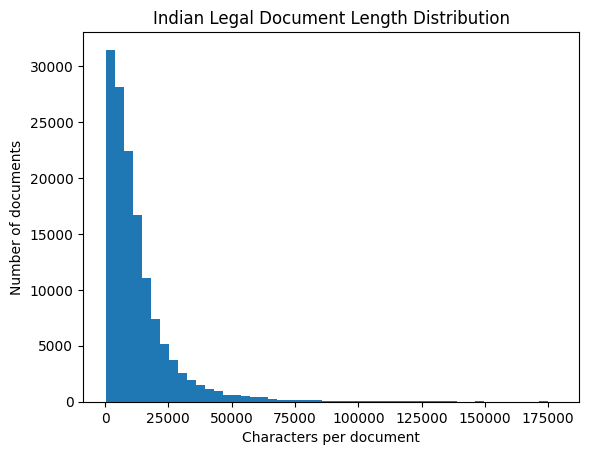

In [8]:
import matplotlib.pyplot as plt

plt.hist(df["char_length"], bins=50)
plt.xlabel("Characters per document")
plt.ylabel("Number of documents")
plt.title("Indian Legal Document Length Distribution")
plt.show()

In [9]:
!pip install -q -U "transformers" "huggingface_hub"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 21.5 MB/s eta 0:00:00


**Note: The GPT-2 tokenizer is used only to estimate token-length statistics. It will not be used as the tokenizer for the final Indian Legal SLM. A domain-specific tokenizer will be trained on the Indian legal corpus in the next stage.**

In [10]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")

def count_tokens(text):
    return len(tokenizer.encode(text, add_special_tokens=False))

df["token_length"] = df["text"].map(count_tokens)

print(df["token_length"].describe())

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (3078 > 1024). Running this sequence through the model will result in indexing errors


count    138321.000000
mean       2804.779166
std        3158.845245
min          57.000000
25%         931.000000
50%        1928.000000
75%        3514.000000
max       42052.000000
Name: token_length, dtype: float64


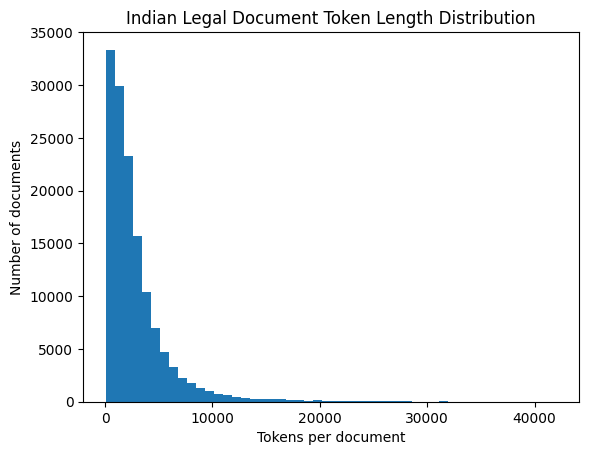

In [11]:
import matplotlib.pyplot as plt

plt.hist(df["token_length"], bins=50)

plt.xlabel("Tokens per document")
plt.ylabel("Number of documents")
plt.title("Indian Legal Document Token Length Distribution")

plt.show()

In [12]:
for length in [256, 512, 1024, 2048, 4096]:
    percentage = (df["token_length"] <= length).mean() * 100
    print(f"{length} tokens: {percentage:.2f}% of documents")

256 tokens: 5.41% of documents
512 tokens: 14.22% of documents
1024 tokens: 27.36% of documents
2048 tokens: 52.52% of documents
4096 tokens: 80.27% of documents


In [13]:
print("Duplicate documents:", df["text"].duplicated().sum())

print(
    "Duplicate percentage:",
    df["text"].duplicated().mean() * 100
)

Duplicate documents: 4665
Duplicate percentage: 3.3725898453597067


In [14]:
empty_docs = df["text"].str.strip().eq("").sum()

print("Empty documents:", empty_docs)

Empty documents: 0
